# Customer Segmentation Analysis
### Using K-Means Clustering

This notebook loads the Mall Customers dataset, preprocesses it, determines the optimal number of clusters using the Elbow Method, trains a K-Means model, and visualizes the resulting customer segments.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")

## 2. Load the Dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")
print("Shape:", df.shape)
df.head()

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,41,25,1
1,2,Female,69,78,76
2,3,Female,28,85,20
3,4,Female,66,88,96
4,5,Male,25,36,23


## 3. Data Cleaning & Exploration

In [3]:
# Check for missing values and duplicates
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
df.describe()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
Duplicate rows: 0


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,45.450000,56.535000,50.545000
std,57.879185,14.616625,29.519583,29.291945
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,34.750000,25.000000,21.000000
50%,100.500000,46.000000,61.000000,53.000000
75%,150.250000,57.000000,83.250000,78.000000
max,200.000000,69.000000,102.000000,100.000000


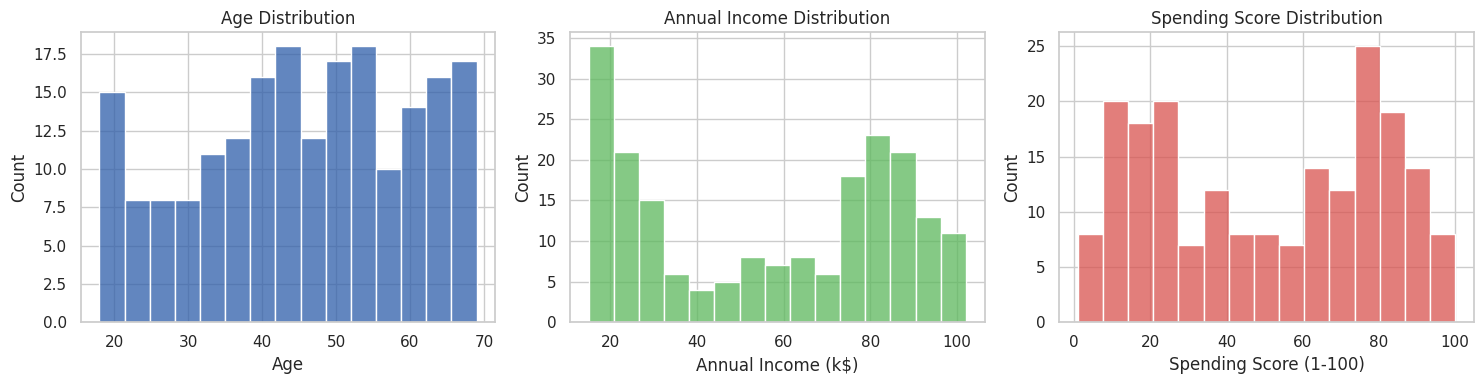

In [4]:
# Quick visual exploration
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["Age"], bins=15, ax=axes[0], color="#2E5EAA")
axes[0].set_title("Age Distribution")

sns.histplot(df["Annual Income (k$)"], bins=15, ax=axes[1], color="#5CB85C")
axes[1].set_title("Annual Income Distribution")

sns.histplot(df["Spending Score (1-100)"], bins=15, ax=axes[2], color="#D9534F")
axes[2].set_title("Spending Score Distribution")

plt.tight_layout()
plt.show()

## 4. Feature Selection & Scaling

In [5]:
# Select features for clustering
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

# Scale features so both contribute equally to distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 5. Determine Optimal Number of Clusters (Elbow Method)

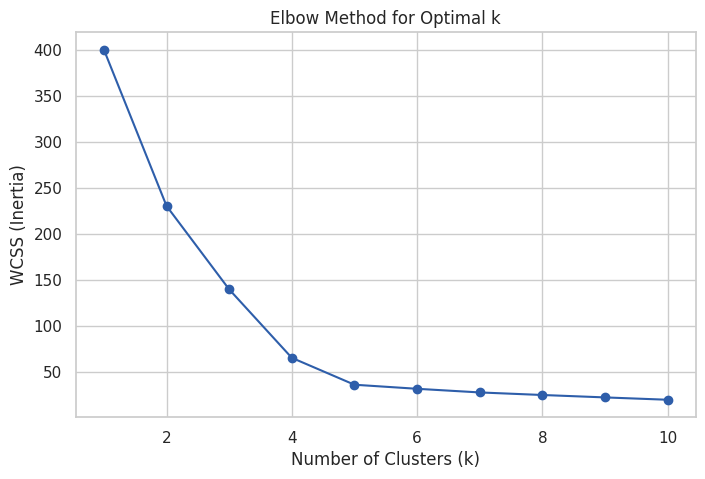

In [6]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), wcss, marker="o", color="#2E5EAA")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.show()

The elbow point occurs around **k = 5**, which we confirm below using the Silhouette Score.

In [7]:
sil_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

for k, score in zip(range(2, 11), sil_scores):
    print(f"k={k}: silhouette score = {score:.3f}")

k=2: silhouette score = 0.412
k=3: silhouette score = 0.461
k=4: silhouette score = 0.569
k=5: silhouette score = 0.609
k=6: silhouette score = 0.550
k=7: silhouette score = 0.507
k=8: silhouette score = 0.485
k=9: silhouette score = 0.448
k=10: silhouette score = 0.393


## 6. Train Final K-Means Model

In [8]:
k_optimal = 5
kmeans = KMeans(n_clusters=k_optimal, init="k-means++", n_init=10, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,41,25,1,3
1,2,Female,69,78,76,1
2,3,Female,28,85,20,0
3,4,Female,66,88,96,1
4,5,Male,25,36,23,3


## 7. Visualize the Clusters

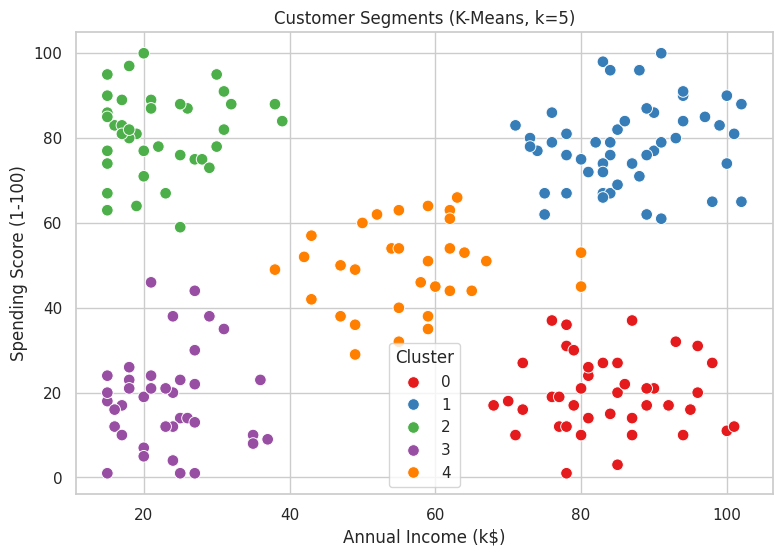

In [9]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
    hue="Cluster", palette="Set1", s=70
)
plt.title("Customer Segments (K-Means, k=5)")
plt.show()

## 8. Interpret the Segments

In [10]:
cluster_summary = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)
cluster_summary["Count"] = df["Cluster"].value_counts().sort_index()
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,47.8,83.8,19.7,41
1,43.5,86.4,78.3,49
2,43.6,22.2,81.2,38
3,46.4,23.3,18.5,38
4,46.5,56.3,49.4,34


## 9. Conclusion

The K-Means model successfully separates customers into five distinct, interpretable segments based on income and spending behavior (e.g. high income-high spenders, low income-high spenders, average customers). These segments can guide targeted marketing, loyalty programs, and personalized offers.